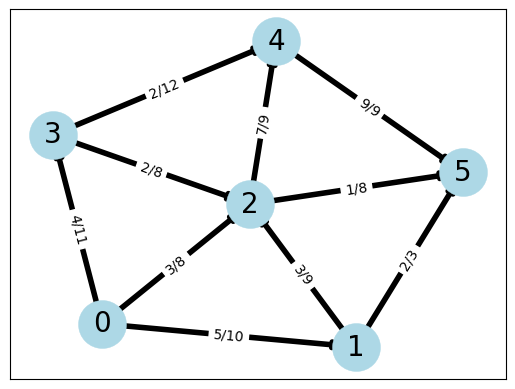

In [8]:
import networkx as nx
import random
import math
from networkx.algorithms.flow import edmonds_karp

import matplotlib.pyplot as plt
def printGraph(G):
    links = [(u, v) for (u, v, d) in G.edges(data=True)]
    pos = nx.nx_pydot.graphviz_layout(G)
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue', linewidths=0.25)
    nx.draw_networkx_edges(G, pos, edgelist=links, width=4)
    nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
    edge_labels = {(u, v): f"{d['flow']}/{d['capacity']}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
    plt.show()

G = nx.DiGraph()
G.add_edges_from(
    [(0,1, {'flow': 5}), (0,1,{'capacity': 10}),
     (0,2, {'flow': 3}), (0,2,{'capacity': 8 }),
     (0,3, {'flow': 4}), (0,3,{'capacity': 11}),
     (1,2, {'flow': 3}), (1,2,{'capacity': 9 }),
     (1,5, {'flow': 2}), (1,5,{'capacity': 3 }),
     (2,4, {'flow': 7}), (2,4,{'capacity': 9 }),
     (2,5, {'flow': 1}), (2,5,{'capacity': 8 }),
     (3,2, {'flow': 2}), (3,2,{'capacity': 8 }),
     (3,4, {'flow': 2}), (3,4,{'capacity': 12}),
     (4,5, {'flow': 9}), (4,5,{'capacity': 9 })])

printGraph(G)

In [9]:
# Successor function
def generateSuccessors(graph, sink, source):
    paths = []
    for path in nx.all_simple_paths(graph, source=source, target=sink):
        paths.append(path)
    return paths

# Heuristic function
def heuristic(graph, path, sink):
    diffValues = []
    for u, v in zip(path, path[1:]):
        diffValues.append(graph[u][v]['capacity'] - graph[u][v]['flow'])

    if not diffValues:
        changeInTerminal = 0
    else:
        changeInTerminal = min(diffValues)

    terminalFlow = 0
    for u, v in graph.edges():
        if v == sink:
            terminalFlow += graph[u][v]['flow']
    terminalFlow += changeInTerminal

    return terminalFlow

# Simulated Annealing
def simulatedAnnealing(graph, source, sink, temperature=100, coolingFactor=0.01):
    successors = generateSuccessors(graph, sink, source)
    while temperature > 10e-3: # choosing the temprate 0.0001 as the breaking point
        currentSolution = []
        currentHeuristic = 0

        for i, successor in enumerate(successors):
            successorHeuristic = heuristic(graph, successor, sink)
            currentHeuristicValue = heuristic(graph, [], sink)
            change = successorHeuristic - currentHeuristicValue

            if change > 0:
                currentSolution = successor
                currentHeuristic = change
                break
            elif change < 0:
                prob = math.exp(change / temperature)
                if random.random() < prob:
                    currentSolution = successor
                    currentHeuristic = change
                    break

        if not currentSolution:
            break

        for i in range(len(currentSolution) - 1):
            graph[currentSolution[i]][currentSolution[i + 1]]['flow'] += currentHeuristic

        temperature *= 1 - coolingFactor
    return graph

def generateRandomGraph(numNodes, connectivity):
    graph = nx.gnp_random_graph(numNodes, connectivity, directed=True)

    for u, v in graph.edges():
        graph[u][v]['capacity'] = random.randint(1, 10)
        graph[u][v]['flow'] = 0

    return graph

def printEdmondsKarp(graph, source, sink, flag=True):
    residualGraph = edmonds_karp(graph, source, sink)
    edmondsKarpValue = nx.maximum_flow_value(residualGraph, source, sink)
    if flag:
        print("Edmonds karp function tf_net ", edmondsKarpValue)
    else:
        return edmondsKarpValue

def printSimulatedAnnealing(graph, source, sink, flag=True):
    obtainedValues = 0
    for u, v in graph.edges():
        if v == sink:
            obtainedValues += graph[u][v]['flow']
    if flag:
        print("Simulated Annealing tf ", obtainedValues)
    else:
        return obtainedValues

# R1

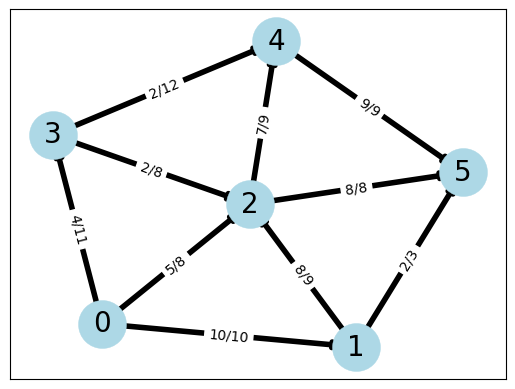

In [10]:
source = 0
sink = 5
G = simulatedAnnealing(G, source, sink)
printGraph(G)

In [11]:
printEdmondsKarp(G, source, sink)
printSimulatedAnnealing(G, source, sink)

Edmonds karp function tf_net  20
Simulated Annealing tf  19


# R2

In [12]:
G = generateRandomGraph(30, 0.1)
source = 0
sink = 29
simulatedAnnealing(G, source, sink)

In [13]:
printEdmondsKarp(G, source, sink)
printSimulatedAnnealing(G, source, sink)

Edmonds karp function tf_net  10
Simulated Annealing tf  10


# R3 with temp 100

In [ ]:
average_edmonds_karp = 0
average_simulated_annealing = 0

for i in range(30):
  G = generateRandomGraph(30, 0.1)
  source = 0
  sink = 29
  simulatedAnnealing(G, source, sink, 100)
  average_edmonds_karp += printEdmondsKarp(G, source, sink, False)
  average_simulated_annealing += printSimulatedAnnealing(G, source, sink, False)


In [15]:
print(f"Average edmonds karp {(average_edmonds_karp / 30):.2f}")
print(f"Average simulated annealing {(average_simulated_annealing / 30):.2f}")

Average edmonds karp 10.10
Average simulated annealing 9.27


# R3 with temp 1000

In [ ]:
average_edmonds_karp = 0
average_simulated_annealing = 0

for i in range(30):
  G = generateRandomGraph(30, 0.1)
  source = 0
  sink = 29
  simulatedAnnealing(G, source, sink, 1000)
  average_edmonds_karp += printEdmondsKarp(G, source, sink, False)
  average_simulated_annealing += printSimulatedAnnealing(G, source, sink, False)


In [17]:
print(f"Average edmonds karp {(average_edmonds_karp / 30):.2f}")
print(f"Average simulated annealing {(average_simulated_annealing / 30):.2f}")

Average edmonds karp 9.97
Average simulated annealing 9.57
